# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Contributions:
- Michelle Lappin:
- Andy Li:
- Cheng-I Lin:
- Tyler Ogawa:
- Navneet Sharma:

# Research Question

What factors can best predict the success of live-service shooters on Steam? Specifically, using pre-launch data (search interest, online activity, and developer/publisher) and early post-launch data (initial price and peak concurrent users), can we determine the factors that most accurately forecast long-term profitability (estimated revenue through review numbers), player retention (average playtime in the last two weeks), and community reception (final positive review percentage)?

## Background and Prior Work


### Background

Steam, one of the most prominent online gaming platforms with millions of daily players, is home to thousands of shooting games. With the intense competition between video games of the same genre, each game must be able to portray and sell their uniqueness to emerge victorious in the rivalry between industries. A game can achieve this through creating outstanding graphical animations, developing special gameplay mechanics, reducing monetary costs, sharing connections to popular series or creators, and marketing to spread awareness. However, if a game fails to do so, it may not meet the expectations of the player community, resulting in what’s known as a flop (collectively acknowledged failures). Therefore, how do the developers and publishers of live-service shooting games anticipate a game’s commercial success of revenue and critical success of player reviews and engagement shortly after launch, or even before release, to prevent flops that can result in financial and occupational risks?

Obviously, factors like price can greatly influence consumer behavior as there are over 1800 free to play shooter games on Steam, with Counter-Strike 2 and PUBG: BATTLEGROUNDS being the most widely known. Yet, even with more expensive price tags, games like Arc Raiders (launched at 40 USD) and Red Dead Redemption 2 (launched at 60 USD) still received great feedback in response to positive early reviews. To fully grasp the correlation between certain factors and a game’s success, our team will analyze the results of pre-launch data and early post-launch data to determine how to best achieve success. We were motivated in this research due to our familiarity in playing video games, especially those that include shooting aspects. Despite playing in the same category of video games, we each have our own personal favorites when it comes down to shooting games. Consequently, we noticed that although every game provides a different experience, we all seem to enjoy those different aspects of the game. Therefore, we are curious to see the impacts on success of the various characteristics a game features.

### Prior Work
Similar questions have been asked by several researchers in the past, for instance, by researcher and data scientist <a href="https://www.researchgate.net/publication/355110719_Predicting_the_Popularity_of_Games_on_Steam">David Nabergoj</a>. David and his team sought out to predict the popularity of games on Steam. To elaborate, the study attempted to discover the relationship between the popularity of the game and its features. Using Bayesian models, the game's popularity was measured before and after its release, which was contingent on its price, storage size, supported languages, release date, and genre. Their findings concluded that a genre-based hierarchical model performed the best, as well as certain genres and early release dates were strongly associated with higher player counts.

The dataset their model operated on consisted of games released after 2015. Gathered from three disparate sources, Steam API, Stream Spy, which offers data not available from Steam's API, and Steam DB, a historical database of player count. Price, and system requirements were the primary aim of their data wrangling procedure. Cheaper games are, generally, more popular, and the more storage a game requires, the greater the budget, inferring the higher the reputation of the game . Upon cleaning their data they were left with a dataset upwards of 8,000 games.

The prediction aimed to correctly analyze the median player count by the second month upon the game's release. By utilizing simple regression models it was found that, not only were most games cheap and minimal in storage size, but overwhelmed by outliers as well. Certain categories such as developers and publishers were dropped from categorical features as there were too many confounding variables. The player counts peaked the first month after release, and numbers plateaued the second. Therefore, it can be said that the first month is paramount in predicting success. Marginal factors included supported languages, storage size, price, and the time at which the game was released.

### References

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Luisa, Andraž, Hartman, Jan, Nabergoj, David, Pahor, Samo, Rus, Marko, Stevanoski, Bozhidar, Demšar, Jure, & Štrumbelj, Erik. (2021). *Predicting the Popularity of Games on Steam.* arXiv. https://doi.org/10.48550/arXiv.2110.02896


# Hypothesis



1. Revenue: We predict that pre-launch search interest will be the strongest predictor of estimated revenue. However, for free-to-play games, peak concurrent users will more accurately forecast revenue in the long term. This is because live-service games rely on recurring transactions for sustained revenue, and rely on a high volume of players.
2. Retention: We predict that revenue will be strongly correlated with a game's initial price and less so with search interest. This is because the hype around a game spikes and dies down gradually over time (exponential decay), and financial investment will drive players to play a game for longer.
3. Reception: We predict that an interaction between initial price and category count (number of features like Steam Achievements or Cloud Save) will correlate with the final positive review percentage. This is because games with a high price point yet low number of features will be perceived to be "lacking polish", and receive more negative reviews.



## Data

### Data overview

- Dataset #1
  - Dataset Name: Steam Web API
  - Link to the dataset: https://steamcommunity.com/dev
  - Number of observations: ~180,000
  - Number of variables: 36
  - Most relevant are: supported_languages, pc_requirements, platforms, genre, categories
    - supported_langauges is stored in a string format containing the language name and some other texts. The other variables (pc_requirements, platforms, genres, and categories) are stored in a list of dictionaries that contain information about each category. These are important features as they provide the general information regarding the metadata of the games. For instance, we can compared how the various language supported or diffferent pc requirements can affect how players view the game, thus allowing us to see if which aspect of the game can boost its success.
  - Shortcomings: Requires a steam account which has spent over $5 in steam. Also rate limits to 1.5s interval requests, making data processing and gathering tedious.
- Datset #2
  - Dataset Name: Google Trends
  - Link to the dataset: https://trends.google.com/trends
  - Number of observations: ~1 billion
  - Number of variables: 1
  - Most relevant are: search_interest
    - Search interest is a relative, normalized metric (0–100) representing a topic's popularity compared to total search volume, not absolute search numbers. A score of 100 indicates peak popularity, 50 means half as popular, and 0 means insufficient data. This is a normalized value, making the comparison between different time periods possible. With this, we can filter the timeframe for pre-launch data that can imply the amount of followers and attentions the game has, providing a metric to how popular a game is.
  - Shortcomings: Only has one variable. Requests also take a while because Google has undisclosed rate limits. Therefore, we need to randomly sample a small amount of games from our SteamSpy dataset so that we can reduce the runtime and have a cleaner dataset.
- Dataset #3
  - Dataset Name: SteamSpy
  - Link to the dataset: https://steamspy.com/api.php
  - Number of observations: ~65,000
  - Number of variables: 20
  - Most relevant are: initialprice, ccu, developer, publisher, positive, negative
    - These are important features as they can be utilized as metrics for our game success indicator. The variable owners depict the range of individuals who own the game in string format, while ccu represents the peak concurrent users in integer format that signifies the maximum total number of players logged in the game during a single time frame. Combining with the variable initialprice (original US price in cents), we can calulate the estimated revenue in sales based on how many people bought the game. Prices of games can vary drastically, from less than 10 to more than 50 dollars depending on the types of games. Besides this, the metadata of the game, such as its developer (string), publisher (string), and the number of positive and negative reviews (interger counts) it received, can also help determine the public recognition and connotation toward the game.
  - Shortcomings: Less accurate because it relies on people setting their profiles to public, since they're private by default. They scrape information from profiles, but with a fraction of the total data, they rely on a lot of statistical inference which can have errors.

To combine these datasets, we start with #2. That one has only one variable so we simply add it as a column to #1. To merge the new #1 and #3, we will use descriptive data from the official API and merge it with variables like positive, negative, and ccu from SteamSpy—these variables don't exist in the official API.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

# %load_ext autoreload
# %autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

# import sys
# sys.path.append('./modules') # this tells python where to look for modules to import

# import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
# datafiles = [
#     { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
#     { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
# ]

# get_data.get_raw(datafiles,destination_directory='data/00-raw/')

In [3]:
import os
import json
import requests
import time
import random
import pandas as pd
from datetime import datetime, timedelta
from pytrends.request import TrendReq

random.seed(42)

def steamspy_data():
    # Setup target directory
    output_dir = "data/00-raw"
    os.makedirs(output_dir, exist_ok=True)
    
    # Use tag to filter by FPS genre
    url = "https://steamspy.com/api.php?request=tag&tag=FPS"
    
    print(f"Fetching data from SteamSpy...")
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        
        data = response.json()
        
        # Filename to save to target directory
        file_path = os.path.join(output_dir, "steamspy.json")
        
        with open(file_path, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=4, ensure_ascii=False)
            
        print(f"Successfully saved {len(data)} games to {file_path}")
        
    except Exception as e:
        print(f"An error occurred: {e}")

# steamspy_data()

In [4]:
def official_data():
    # Filename and name of SteamSpy file.
    raw_path = "data/00-raw/steamspy.json"
    output_path = "data/00-raw/steamapi.json"

    with open(raw_path, "r", encoding="utf-8") as f:
        steamspy_data = json.load(f)

    # Random sample to save time
    app_ids = list(steamspy_data.keys())
    random.shuffle(app_ids)
    target_ids = app_ids[:200]

    # Storage dictionary
    detailed_results = {}
    
    print(f"Starting requests...")
    
    for i, app_id in enumerate(target_ids):
        # Steam Store API
        url = f"https://store.steampowered.com/api/appdetails?appids={app_id}"
        
        try:
            response = requests.get(url)
            
            if response.status_code == 429:
                print("Rate limit hit! Sleeping for 30 seconds...")
                time.sleep(30)
                continue
                
            data = response.json()
            
            if data and data[str(app_id)]["success"]:
                game_info = data[str(app_id)]["data"]
                detailed_results[app_id] = game_info
                print(f"[{i+1}/200] Fetched: {game_info.get('name')}")
            else:
                print(f"[{i+1}/200] Failed to get data for ID: {app_id}")

        except Exception as e:
            print(f"Error fetching {app_id}: {e}")
        
        # Try to avoid rate limits
        time.sleep(1.5)

    # Save results
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(detailed_results, f, indent=4, ensure_ascii=False)
    
    print(f"\nFinished! Detailed data saved to {output_path}")

# Requires SteamSpy list to exist before running.
# official_data()

In [5]:
def trends_data():
    input_path = "data/00-raw/steamapi.json"
    output_path = "data/00-raw/trends.csv"
    
    if not os.path.exists(input_path):
        print("Error: steamapi.json not found.")
        return

    with open(input_path, "r", encoding="utf-8") as f:
        games_data = json.load(f)

    pytrends = TrendReq(hl="en-US", tz=360)
    results = []

    print(f"Processing {len(games_data)} games...")

    for i, (app_id, details) in enumerate(games_data.items()):
        game_name = details.get("name")
        release_info = details.get("release_date", {})
        date_str = release_info.get("date")
    
        if not date_str:
            continue
            
        try:
            # Convert to datetime
            launch_date = pd.to_datetime(date_str)
            
            # Timeframe is 30 days before launch to launch day
            start_date = (launch_date - timedelta(days=30)).strftime("%Y-%m-%d")
            end_date = launch_date.strftime("%Y-%m-%d")
            timeframe = f"{start_date} {end_date}"
            
            print(f"[{i+1}/200] Fetching Trends for: {game_name} ({timeframe})")

            # Search for interest over time
            pytrends.build_payload([game_name], cat=0, timeframe=timeframe, geo="")
            df = pytrends.interest_over_time()

            avg_interest = 0
            if not df.empty and game_name in df.columns:
                avg_interest = df[game_name].mean()

            # Append to our list
            results.append({
                "name": game_name,
                "launch_date": end_date,
                "search_interest": float(avg_interest)
            })
            
            print(f"Saved: {game_name} | Score: {avg_interest}")

            # Save every time
            pd.DataFrame(results).to_csv(output_path, index=False)
        
        except Exception as e:
            print(f"Skipping {game_name}: {e}")
        
        # To avoid harsh rate limits
        time.sleep(5)

    print(f"Done! Trends saved to {output_path}")

# Needs `pip install pytrends`
# trends_data()

### Steam Shooter Performance & Market Success Dataset

This dataset integrates metadata and performance metrics from the Steam Web API, SteamSpy, and Google Trends to analyze the commercial and critical success of shooter games. It combines pre-launch interest with post-launch outcomes such as financial revenue, player retention, and community sentiment. The data is structured at the individual game level, allowing for a multifaceted look at how marketing "hype" translates into long-term sustainability on the Steam platform.

Key Variables:
- Estimated Revenue (USD): This is a calculated heuristic which uses review counts as a proxy for sales. For paid games, it is calculated as #Reviews x 30 x Price, while for free-to-play games, a multiplier of 75 is used to account for in-game microtransactions. While not an absolute measurement, it provides a relative scale of commercial success.
- Search Interest (Index 0-100): Sourced from Google Trends, this represents relative search volume normalized to the peak popularity within 30 days before launch. A value of 100 represents the peak of public interest, while 50 indicates the topic was half as popular.
- Community Reception (Percentage 0.0-1.0): Calculated as the number of positive reviews divided by total reviews. A value of 0.90 or higher generally corresponds to an "Overwhelmingly Positive" rating on Steam, whereas values below 0.40 indicate "Mostly Negative".
- Player Retention (Minutes): Represented by the average_2weeks variable, this measures the average time in minutes players spent in-game over the most recent 2 week period.
- CCU (Count): Peak Concurrent Users. This represents the highest number of players logged into the game simultaneously. For shooters, below 500 is unhealthy and over 10,000 is extreme success.

Data Limitations and Concerns:
- SteamSpy data is the source for review counts and CCU, but because Steam user profiles are private by default, SteamSpy uses sampling and statistical inference to estimate these numbers. This introduces a margin of error, particularly for niche games with smaller player bases where the sample size is lower.
- The estimated_revenue calculation relies on the assumption that a consistent ratio of players leaves reviews. However, this ratio can fluctuate wildly based on a game's reputation or community sentiment; a frustrated community might leave more reviews (negative) than a content one, potentially bloating the revenue estimate for poorly received games.
- Google Trends data for search interest can be noisy if a game has a generic title (e.g., "Squad" or "Control"). While efforts are made to clean the names, some search volume may reflect general vocabulary rather than interest in the specific video game.

In [6]:
import numpy as np

# Load data
trends_df = pd.read_csv("data/00-raw/trends.csv")
with open("data/00-raw/steamapi.json", "r") as f:
    api_data = json.load(f)
with open("data/00-raw/steamspy.json", "r") as f:
    spy_data = json.load(f)

# Process JSON
api_records = []
for appid, d in api_data.items():
    if d:
        api_records.append({
            "appid": d.get("steam_appid"),
            "name": d.get("name"),
            "is_free": d.get("is_free"),
            "developers": ", ".join(d.get("developers", [])),
            "publishers": ", ".join(d.get("publishers", [])),
            "categories_count": len(d.get("categories", []))
        })
api_df = pd.DataFrame(api_records)

# Process JSON again
spy_records = []
for appid, d in spy_data.items():
    if d:
        spy_records.append({
            "appid": d.get("appid"),
            "positive": d.get("positive", 0),
            "negative": d.get("negative", 0),
            "initialprice": float(d.get("initialprice", 0)) / 100.0,
            "price": float(d.get("price", 0)) / 100.0,
            "ccu": d.get("ccu", 0),
            "average_2weeks": d.get("average_2weeks", 0)
        })
spy_df = pd.DataFrame(spy_records)

# Merge
games_meta = pd.merge(api_df, spy_df, on="appid", how="inner")
trends_df["name_clean"] = trends_df["name"].str.lower().str.strip()
games_meta["name_clean"] = games_meta["name"].str.lower().str.strip()
final_df = pd.merge(trends_df, games_meta, on="name_clean", how="inner")

# Target variables
final_df["total_reviews"] = final_df["positive"] + final_df["negative"]
final_df["estimated_revenue"] = np.where(
    final_df["is_free"],
    final_df["total_reviews"] * 75,
    final_df["total_reviews"] * 30 * final_df["price"]
)
final_df["community_reception"] = (final_df["positive"] / final_df["total_reviews"]).fillna(0)
final_df["player_retention"] = final_df["average_2weeks"]

# This has already been done, no need to redo. Files are found in data/02-processed
# Tidy and save
final_cols = [
    "name_x", "launch_date", "search_interest", "developers", "publishers",
    "categories_count", "initialprice", "ccu", "is_free",
    "estimated_revenue", "community_reception", "player_retention"
]
# processed_df = final_df[final_cols].rename(columns={"name_x": "name"})
# output_dir = "data/02-processed"
# file_name = "shooter_performance_data.csv"
# full_path = os.path.join(output_dir, file_name)
# processed_df.to_csv(full_path, index=False)

## Results

### Exploratory Data Analysis
In this section, we examine the processed dataset `shooter_performance_data.csv` to identify the distributions and correlations that define "success" on Steam. We specifically focus on the differing behaviors between free and paid titles. Our goal is to assess whether pre-launch hype (search interest) translates into long-term financial success and whether category count actually impacts community sentiment.

In [7]:
# Quick Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from modules.eda_helpers import plot_relationship, plot_distribution

data_path = "data/02-processed/shooter_performance_data.csv"
df = pd.read_csv(data_path)
df.head()

,name,launch_date,search_interest,developers,publishers,categories_count,initialprice,ccu,is_free,estimated_revenue,community_reception,player_retention
0,Grounded Sim,2024-04-27,0.000000,Steven Steele,WoozaStudios,3,0.00,0,False,0.0,0.855856,0
1,Sudeki,2014-02-24,4.774194,Climax Studios,Climax Group,6,5.99,3,False,178082.7,0.886983,0
2,FUBG: FIGHT UNKNOWN BATTLEGROUND,2024-05-25,3.225806,GameX Limited,GameX Limited,5,4.99,0,False,149.7,0.000000,0
3,NEKOPARA Vol. 3,2017-05-25,0.000000,NEKO WORKs,Sekai Project,5,9.99,15,False,1780382.1,0.970066,2
4,Hellbound: Survival Mode,2019-11-22,0.000000,Saibot Studios,Saibot Studios,4,0.00,1,True,144225.0,0.874155,0


#### Section 1: Distributions and Variable Quality

Before testing relationships, we must understand the shape of our success variables. Success on Steam is often extremely polarized, meaning we expect highly skewed distributions where a few hits dominate the revenue and player counts.

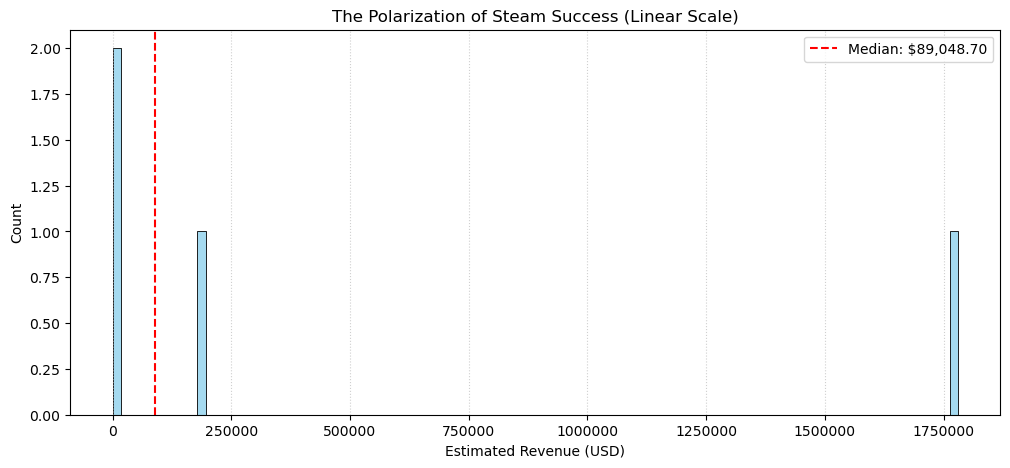

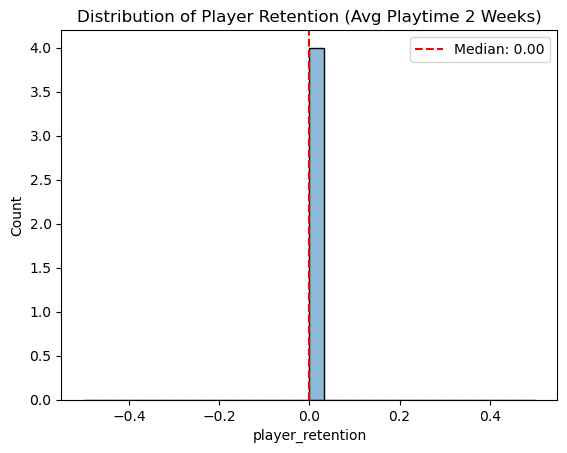

,search_interest,ccu,initialprice,categories_count
count,4.000000,4.000000,4.000000,4.000000
mean,2.750000,4.500000,4.242500,4.750000
std,1.936447,7.141428,4.642739,1.258306
min,0.000000,0.000000,0.000000,3.000000
25%,2.419355,0.000000,0.742500,4.500000
50%,3.225806,1.500000,3.490000,5.000000
75%,3.556452,6.000000,6.990000,5.250000
max,4.548387,15.000000,9.990000,6.000000


In [44]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="estimated_revenue", bins=100, color='skyblue')
median_val = df['estimated_revenue'].median()
plt.axvline(median_val, color='red', linestyle='--', label=f"Median: ${median_val:,.2f}")
plt.title("The Polarization of Steam Success (Linear Scale)")
plt.xlabel("Estimated Revenue (USD)")
plt.ticklabel_format(style='plain', axis='x') # Removes scientific notation 
plt.grid(axis='x', linestyle=':', alpha=0.6) 
plt.legend()
plt.show()

plot_distribution(df, "player_retention", "Distribution of Player Retention (Avg Playtime 2 Weeks)")

df[["search_interest", "ccu", "initialprice", "categories_count"]].describe()

#### Section 2: Testing Hypotheses

In this section we visualize the interactions proposed in our hypotheses.

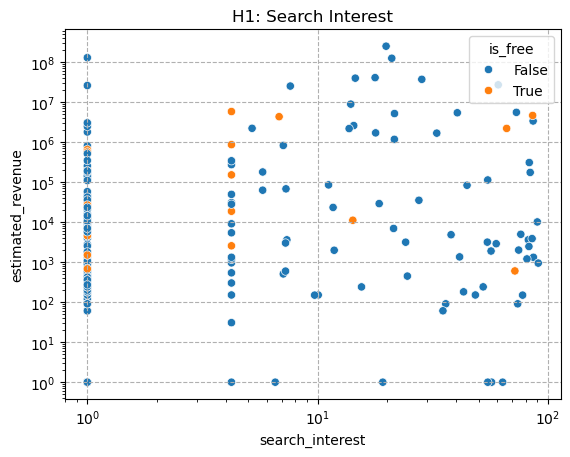

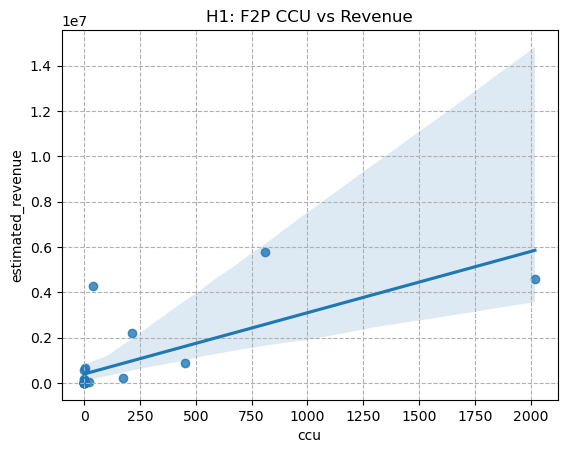

In [9]:
# Hypothesis 1: Revenue Drivers (Search Interest vs. Peak Users)
# Split by is_free status

plot_relationship(df, x="search_interest", y="estimated_revenue", hue="is_free", title="H1: Search Interest", log_scale=True)

# To see free games specifically
f2p_df = df[df["is_free"] == True]
plot_relationship(f2p_df, x="ccu", y="estimated_revenue", title="H1: F2P CCU vs Revenue")

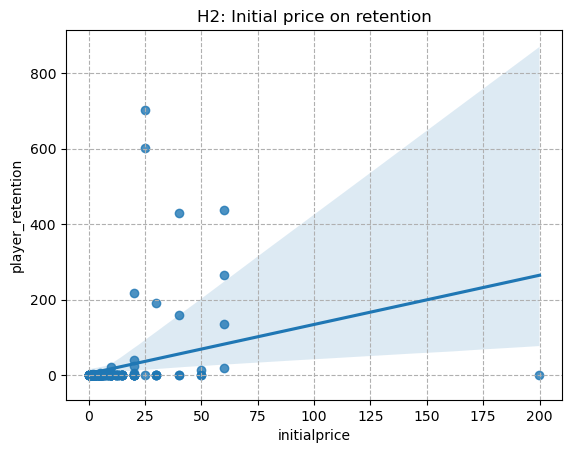

In [10]:
# Hypothesis 2: Retention and Sunk Cost
# Exclude free games to compare price

paid_df = df[df["is_free"] == False]
plot_relationship(paid_df, x="initialprice", y="player_retention", title="H2: Initial price on retention")

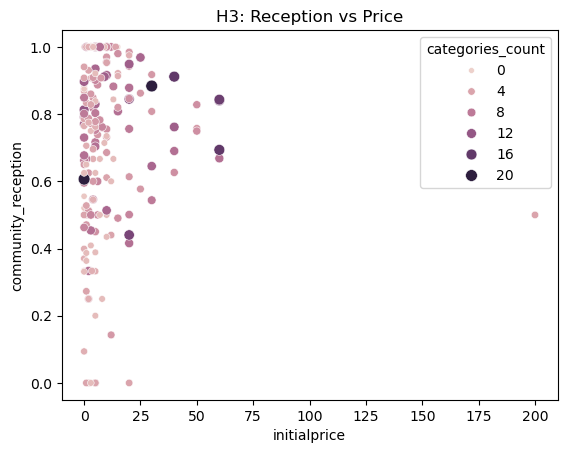

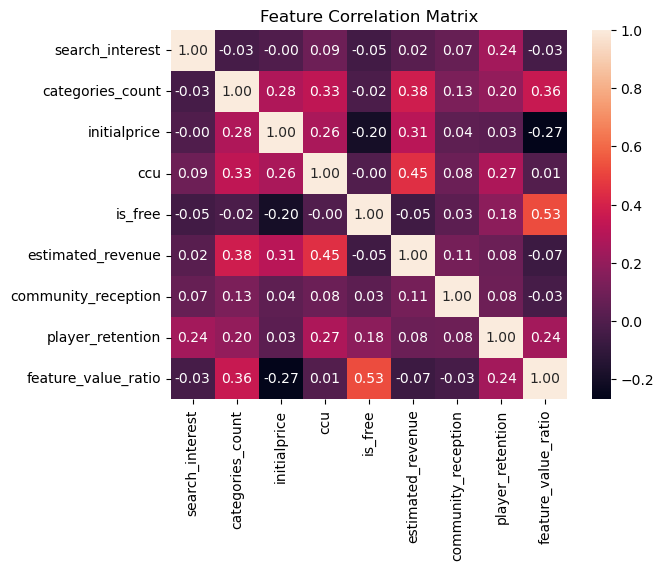

In [11]:
# Hypothesis 3: Reception and Polish

df["feature_value_ratio"] = df["categories_count"] / (df["initialprice"] + 1)

sns.scatterplot(data=df, x="initialprice", y="community_reception", size="categories_count", hue="categories_count")
plt.title("H3: Reception vs Price")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

### EDA Results Analysis

#### Section 1:

- The summary statistics confirm the highly skewed environment of the Steam marketplace. With a mean CCU of 158.9 but a median of 0.0, the vast majority of shooters fail to maintain an active player base, while a few hits drive the averages upward.

#### Hypotheses Section

Hypothesis 1:
- From the first graph we can see that pre-launch search interest has a massive vertical spread, meaning it is a noisy predictor on its own. A game with low search interest can still vary from 10^0 to 10^8 in revenue.
- However, the "F2P CCU vs Revenue" plot shows a clearer positive correlation. As predicted, post-launch concurrent users are a more reliable indicator of revenue for free titles than pre-launch search interest.

Hypothesis 2:
- The "Initial price on retention" plot shows a slight upward trend, but the confidence interval (shaded in blue) widens significantly as price increases.
- This does not fully support our hypothesis. While there is a positive slope, the data points are mostly clustered in the bottom-left. A few high-priced outliers have high retention, but many paid games still result in zero retention, suggesting that the sunk cost of paid games isn't enough to ensure player retention.

Hypothesis 3:
- The heatmap and scatter plot provide the strongest evidence for how features impact success. The scatter plot shows that games with higher category counts (darker, larger dots) tend to cluster in the upper-tier of community reception (>0.6), regardless of price.
- There is a dense cluster of games between 0 and 25 dollars with very low category counts that suffer from poor reception (<0.4).
- The Correlation Matrix reveals that categories_count has a stronger positive correlation with estimated_revenue (0.38) and ccu (0.33) than initialprice does (0.31 and 0.26 respectively). This suggests that feature density is a better predictor of success than the price tag itself.

## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> All user data originates from the Steam API, where users agree to data usage through Steam’s Privacy Policy and EULA before creating accounts. We only access publicly available information permitted under these agreements and do not collect private or restricted user data.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> We recognize that Steam users, FPS players specifically, may not represent the broader gaming population. FPS communities tend to skew toward certain demographics like gender and age, which may bias measures of “success.” We account for this by interpreting findings as specific to the Steam FPS ecosystem rather than generalizing to all gamers. 

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> Usernames may appear in raw datasets as identifiers but are only used internally for deduplication and record matching. All personally identifiable information is removed or anonymized prior to analysis and reporting to prevent traceability to individuals. 

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?
> Because demographic attributes such as race or gender are not available in the dataset, we acknowledge that we cannot directly test for group-level disparities. We therefore avoid making claims about demographic fairness and limit conclusions strictly to observable behavioral metrics.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> All datasets are stored on secured, access-controlled systems. Only project members have access, and files are shared through encrypted platforms to minimize risk of unauthorized exposure.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> Since we use publicly available data and anonymize it before analysis, individuals are not directly identifiable. If requested, any raw records associated with a user can be removed from local copies of the dataset.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> Data will be retained only for the duration of the project. Unnecessary or intermediate files will be deleted, and all raw data will be securely removed after analysis is complete. 

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> We discuss assumptions within the team and consider how different stakeholders (developers, players, underrepresented groups) might interpret the results to reduce blind spots in our conclusions.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

>We examine the dataset for potential sources of bias such as overrepresentation of highly popular games, underrepresentation of niche titles, missing values, and class imbalance. Because Steam users and FPS players may not reflect the broader gaming population, we interpret results within this context and avoid generalizing beyond the platform. Where appropriate, we use normalization or stratified analysis to reduce skewed outcomes.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> Visualizations and summaries are designed to avoid misleading scales. We report uncertainty and limitations alongside results.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

>Personally identifiable information, including usernames, is used only temporarily for internal data cleaning and record matching. All identifying information is removed or anonymized before analysis and is never included in visualizations, reports, or shared outputs. Results are presented only in aggregated form to protect individual privacy.

> Data used from Steam users will be identified as their public usernames, but that information will not be publicly shared in our data. Usernames are used as a unique identifier, as we go through all the datasets, but are completely irrelevant and will not be presented in our findings. 

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> All preprocessing and modeling steps are documented and reproducible through code and version control to allow future review or correction.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

>We avoid using features that may indirectly encode sensitive attributes. Only gameplay and performance-related metrics are included.

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

> Although demographic labels are unavailable, we test model performance across different game sizes and popularity levels to ensure predictions are not disproportionately skewed toward certain subsets.

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

>We evaluate multiple performance metrics rather than optimizing for a single score to avoid misleading conclusions. For example, we consider accuracy alongside precision/recall or error-based measures to ensure the model performs consistently across different scenarios and does not favor one type of outcome at the expense of others.

 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

>We prioritize interpretable modeling approaches and provide clear explanations of how predictions are generated. Feature importance and model behavior are documented so stakeholders can understand which factors influence outcomes and can question or validate decisions when needed.

 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

>We explicitly communicate that predictions are correlational, depend on historical Steam data, and may not generalize to other platforms or future trends.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

>If deployed, the model’s performance would be monitored regularly to detect performance degradation, bias, or changes in data patterns over time like new gaming trends or shifts in player behavior. Periodic evaluations and retraining would be conducted to ensure the model remains accurate, fair, and aligned with its intended purpose.

 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

> If harm or misuse is identified, we will investigate, adjust the model, or remove problematic features.

 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

>Deployment would allow the model to be disabled or reverted to previous versions if issues arise.

 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

>We caution that predictions should inform analysis rather than replace human judgment, reducing the risk of misuse in decision-making.


## Team Expectations 

- Communication: Will be held through a Discord group chat. Regarding frequency, a response to a message should be expected within 24 hours. Meetings should be weekly, virtually, or in-person.
- Tone: Needs to be to the point, but also polite. The heart behind discussion should be to contribute positively to the project while not being personal. Likewise, criticism is permitted but should be constructive to the group effort.
- Decision making: Major decisions should be addressed before the whole group. If decision conflicts arise, a majority vote should make the decision. 
- Tasks: Should be initially voluntary, that is, if someone feels more comfortable/knowledgeable than others at a certain task, they should take it. Leftover roles can be assigned to fill tasks.
- Literal conflicts: Initially can be mentioned in chat to address issues that might arise. If still not resolved, it should be addressed in a call to avoid misinterpretations over text.

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them


| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/2/26  |  2 PM | Review any potential concerns with project proposal. Ensure that all of the variables we mentioned in our proposal seem accessible and lead to meaningful results. Assign specific tasks to each teammate. Search for databases. | Final revisions, review and submission of proposals. Ensure everyone is up to date. Discuss project strengths/weaknesses and confirm task assignments.| 
| 2/9/26  |  2 PM | Check in and make sure that the individual tasks assignment in the previous meetings were completed. | Update each other on progress. Decide best methods to handle and scrape data regarding Steam databases.| 
| 2/16/26  |  2 PM | Investigate data through SteamSpy to get estimates of variables (revenue, feedback & reviews) and look for promising data. Narrow down which databases work best for which variables to account for. Verify integrity and compatibility of the player data. | Share results with the team. Investigate random samples, merge databases and calculate revenues. Discuss other variables to pivot to (early access/beta access player numbers) since access of some variables (pre-release data) is infavorable. Assign data wrangling and data description tasks.| 
| 2/23/26  | 2 PM  | Review previously mentioned goals and tasks for meeting. Individually evaluate data presentation ideas, charts, and organization. Vote which ones work best for our project | Report any issues that come up, being mindful of any problems which the project depends on to move forward. If important issues arise, rearrange workload, putting them at first priority. Make an emergency meeting one week from then. For example, if a team member is struggling with extrapolating information from certain data, or we find that one task demands more attention than others/is more difficult than we had initially planned, we will reallocate our efforts towards accomplishing that. Once that is done, make another checkpoint. |
| 3/2/26 (If we had aforementioned issues)  | 2 PM  | Address the aforementioned issues | Check in to make sure the issues are no longer a problem. Reevaluate priorities and divide tasks once more accordingly.  |
| 3/9/26  | 2 PM  | Work on slideshow by generating graphs and visuals that adequately presents our data. Write descriptions that explains correlations between our visuals and our data. |Have entire team ensure that visuals, tests and data makes sense (Compare with third-party websites with similar topics and research). Finalize Slideshow. Make any adjustments if needed. Plan and start creating a video to present the data. |
| 3/17/26  | 2 PM  |Finalize/Turn in project and video. |Confirm everyone is satisfied with the project and that all aspects are completed including the project video.  |
